In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [7]:
uploaded = files.upload()

Saving sample2.jpg to sample2.jpg


In [8]:
img = cv2.imread("sample2.jpg")

In [9]:
if img is None:
    print("Image not loaded!")
else:
    print("Image loaded successfully!")

Image loaded successfully!


In [10]:
def auto_brightness_contrast(image, clip_hist_percent=25):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    hist = cv2.calcHist([gray], [0], None, [256], [0,256]).flatten()
    acc = np.cumsum(hist)

    clip = clip_hist_percent * (acc[-1] / 100.0) / 2.0

    min_gray = np.searchsorted(acc, clip)
    max_gray = np.searchsorted(acc, acc[-1] - clip)

    alpha = 255 / (max_gray - min_gray + 1e-5)
    beta = -min_gray * alpha

    return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

In [11]:
enhanced = auto_brightness_contrast(img)
resized = cv2.resize(enhanced, (1080, 1080))

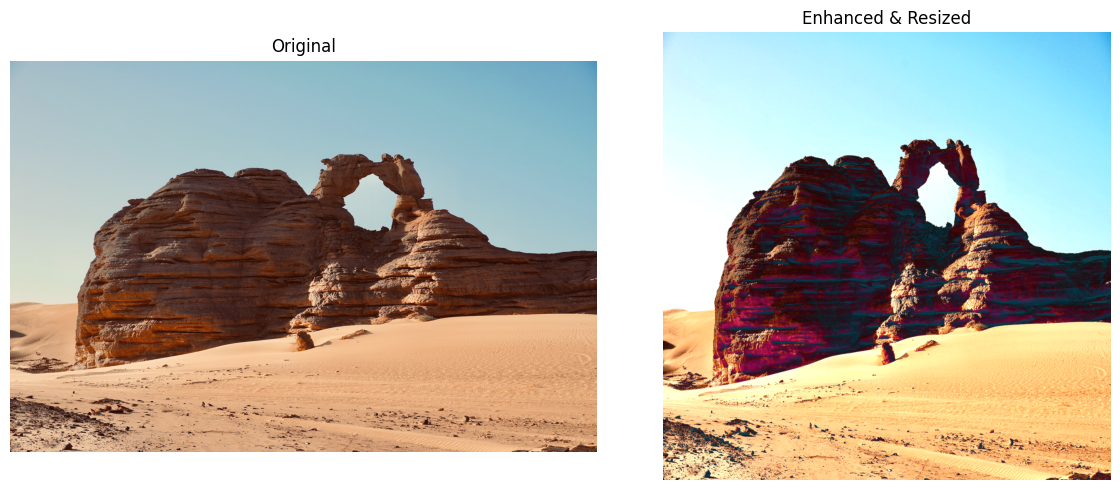

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
ax[1].set_title("Enhanced & Resized")
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()